# RAG 设计范式驱动下的 text2SQL 实践

## 1. RAG 除了用于智能问答外，也可以作为一种设计范式和解决方案

近年来，**检索增强生成（Retrieval-Augmented Generation, RAG）** 技术因其在提升大语言模型（LLM）准确性、可解释性和上下文相关性方面的显著优势，被广泛应用于智能问答系统。然而，RAG 的价值远不止于此——它不仅仅是一种技术工具，更是一种**通用的设计范式与架构思想**。

传统上，我们习惯将 LLM 视为“黑盒”推理引擎：输入自然语言，输出结构化结果。但这种方式在面对专业性强、知识更新频繁或领域敏感的任务时往往表现不佳。而 RAG 提供了一种全新的思路：**先从外部知识库中检索相关信息，再将其作为上下文注入生成过程**，从而实现对模型能力的动态扩展。

这种“**检索 + 上下文增强 + 生成**”的三段式流程，不仅适用于开放域问答，还可迁移到代码生成、数据查询、决策支持等复杂任务中。尤其是在 **text2SQL** 这类需要高度精确语义理解与数据库结构匹配的问题上，RAG 展现出强大的适应性与工程可行性。

因此，本文提出一个核心观点：  
> **RAG 不仅是智能问答的技术手段，更是一种可复用、可组合、可扩展的软件设计范式（Design Pattern），能够有效解决结构化信息转换中的歧义与上下文缺失问题**。


## 2. RAG 的通用能力

RAG 的本质在于打破大模型“静态训练 + 泛化推理”的局限，通过引入外部知识源，赋予其动态获取实时、准确、特定领域信息的能力。其核心能力包括：

### （1）上下文感知增强
RAG 能够根据用户请求动态检索最相关的上下文片段，并将其拼接进 prompt 中，使 LLM 在生成过程中拥有更多背景信息，减少幻觉（hallucination）。

### （2）知识解耦与更新灵活
不同于微调（fine-tuning），RAG 将知识存储与模型参数分离。这意味着：
- 知识可以独立更新（如新增表结构、业务规则）
- 模型无需重新训练即可反映最新状态
- 支持多租户、多数据库环境下的快速适配

### （3）可解释性与可控性提升
由于检索结果可见，我们可以追溯生成依据，判断回答是否基于真实数据，增强了系统的透明度与可信度。

### （4）跨模态与异构数据融合潜力
RAG 可集成多种类型的知识源，如文档、Schema 定义、历史 SQL、注释说明、API 接口文档等，形成统一的上下文供给机制。

### （5）低延迟迭代与低成本部署
相比训练大型模型，构建向量数据库并进行检索的成本更低，且支持增量索引更新，适合企业级高频调用场景。

这些能力使得 RAG 成为连接“人类意图”与“机器执行”的理想桥梁，尤其适合那些需要**高精度语义解析 + 动态知识响应**的任务。


## 3. 以 text2SQL 为例，如何将 RAG 范式融合？为何 RAG 适合 text2SQL 业务？

### 什么是 text2SQL？

text2SQL 是指将自然语言问题自动转化为结构化查询语言（SQL）的过程。例如：

> 用户提问：“上个月销售额最高的产品是什么？”  
> → 目标 SQL：`SELECT product_name FROM sales WHERE month = '2025-09' ORDER BY revenue DESC LIMIT 1;`

尽管 LLM 具备一定的语法理解和生成能力，但在实际应用中仍面临诸多挑战：

| 挑战 | 描述 |
|------|------|
| 表名/字段名不一致 | 自然语言使用“客户”，数据库字段却是 `cust_id` |
| 缺乏 Schema 上下文 | 模型不知道哪些表存在、如何关联 |
| 多义词歧义 | “销量”是指数量还是金额？ |
| 时间表达模糊 | “最近”是7天还是30天？依赖业务定义 |
| 权限与安全限制 | 需要过滤敏感字段或加入 WHERE 条件 |

### 为什么 RAG 特别适合解决 text2SQL？

####  匹配 RAG 核心优势
| RAG 能力 | 在 text2SQL 中的应用 |
|--------|---------------------|
| 上下文增强 | 注入数据库 schema、字段说明、示例 SQL |
| 动态知识注入 | 实时同步最新的表结构变更 |
| 减少幻觉 | 所有生成都基于真实存在的表和字段 |
| 可解释性 | 可追踪生成 SQL 所依据的 schema 或样例 |

![nl2sql](./nl2sql.png)

####  构建高效的“语义桥”
RAG 可以建立一条从“自然语言”到“数据库结构”的映射路径：

```
[用户问题]
    ↓
[Embedding 查询] → [向量数据库]
    ↓               ↳ 包含：表结构、字段描述、别名映射、历史 SQL 示例
[Top-k 最相关 schema 片段]
    ↓
[构造 Prompt]
    ↓
[LLM 生成 SQL]
```

####  支持复杂查询场景
对于涉及多表 JOIN、聚合函数、子查询等情况，仅靠模型记忆难以保证正确性。而通过 RAG 检索出相关的 join 关系图谱或历史复杂查询样本，能显著提高生成质量。

### 实践案例示意

假设数据库中有以下两张表：

```sql
-- 表：products
id | name           | category_id

-- 表：categories
id | name_en        | name_zh
```

用户问：“手机类商品有哪些？”

若无上下文，模型可能误认为 `category_id=3` 对应“手机”。但通过 RAG 检索到如下元数据：

```json
{
  "table": "categories",
  "field": "name_zh",
  "value": "手机",
  "mapped_to": "category_id=5"
}
```

结合该信息后，LLM 更有可能生成正确的 SQL：

```sql
SELECT p.name FROM products p 
JOIN categories c ON p.category_id = c.id 
WHERE c.name_zh = '手机';
```


## 4. Vanna 软件的原理和使用

[Vanna.AI](https://vanna.ai) 的核心是一个 Python 包，，专为 **text2SQL 任务设计**，其核心正是基于 **RAG 范式**构建而成。它允许开发者通过简单的 API 快速搭建一个可训练、可持续演进的自然语言转 SQL 系统。

### 核心设计理念

Vanna 的工作流程完全遵循 RAG 范式：

1. **训练阶段（知识录入）**
   - 用户提供数据库 schema（DDL）、字段说明、示例问答对（NL-SQL pair）
   - Vanna 将这些信息编码为嵌入向量，存入向量数据库（如 Chroma、Milvus）

2. **推理阶段（RAG 流程）**
   - 用户输入自然语言问题
   - Vanna 使用 embedding 模型检索最相关的 schema 和历史 SQL 示例
   - 构造包含上下文的 prompt 发送给 LLM
   - LLM 输出最终 SQL 并返回结果

3. **反馈闭环**
   - 若 SQL 错误，用户可纠正并提交
   - 新的 (question, corrected_sql) 对被加入训练集，持续优化检索效果

![vanna](./vanna.gif)

### 快速使用示例


In [ ]:
!pip install 'vanna[chromadb,openai]'

Adding ddl: CREATE TABLE [Album]
(
    [AlbumId] INTEGER  NOT NULL,
    [Title] NVARCHAR(160)  NOT NULL,
    [ArtistId] INTEGER  NOT NULL,
    CONSTRAINT [PK_Album] PRIMARY KEY  ([AlbumId]),
    FOREIGN KEY ([ArtistId]) REFERENCES [Artist] ([ArtistId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION
)
Adding ddl: CREATE TABLE [Artist]
(
    [ArtistId] INTEGER  NOT NULL,
    [Name] NVARCHAR(120),
    CONSTRAINT [PK_Artist] PRIMARY KEY  ([ArtistId])
)
Adding ddl: CREATE TABLE [Customer]
(
    [CustomerId] INTEGER  NOT NULL,
    [FirstName] NVARCHAR(40)  NOT NULL,
    [LastName] NVARCHAR(20)  NOT NULL,
    [Company] NVARCHAR(80),
    [Address] NVARCHAR(70),
    [City] NVARCHAR(40),
    [State] NVARCHAR(40),
    [Country] NVARCHAR(40),
    [PostalCode] NVARCHAR(10),
    [Phone] NVARCHAR(24),
    [Fax] NVARCHAR(24),
    [Email] NVARCHAR(60)  NOT NULL,
    [SupportRepId] INTEGER,
    CONSTRAINT [PK_Customer] PRIMARY KEY  ([CustomerId]),
    FOREIGN KEY ([SupportRepId]) REFERENCES [Employee] ([Emp

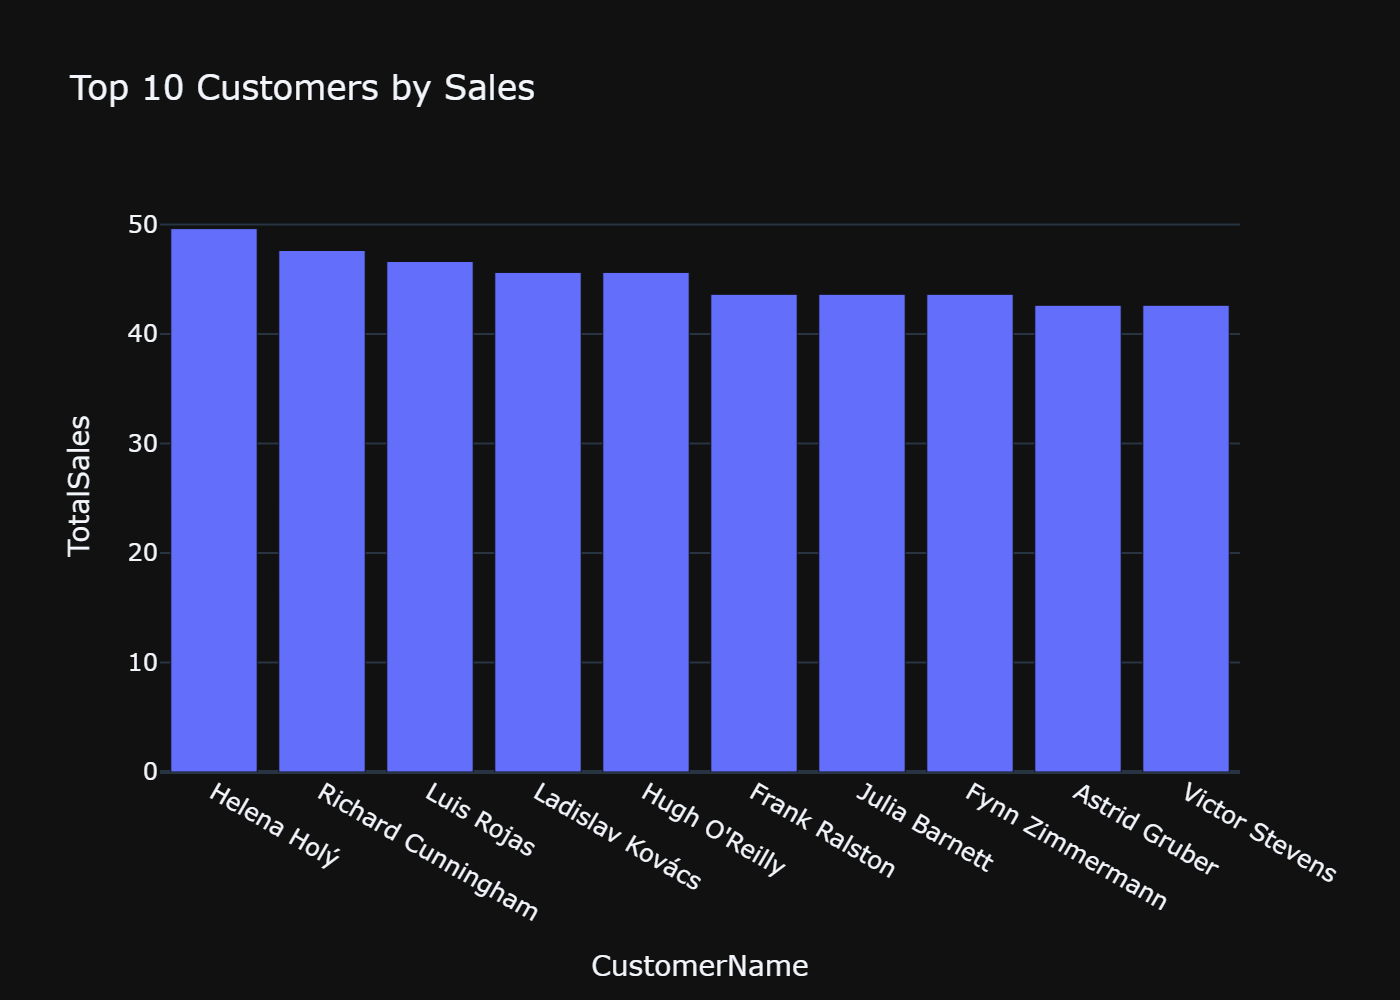

("SELECT \n    c.FirstName || ' ' || c.LastName AS CustomerName, \n    SUM(i.Total) AS TotalSales\nFROM \n    Customer c\nJOIN \n    Invoice i ON c.CustomerId = i.CustomerId\nGROUP BY \n    c.CustomerId\nORDER BY \n    TotalSales DESC\nLIMIT 10;",          CustomerName  TotalSales
0         Helena Holý       49.62
1  Richard Cunningham       47.62
2          Luis Rojas       46.62
3     Ladislav Kovács       45.62
4       Hugh O'Reilly       45.62
5       Frank Ralston       43.62
6       Julia Barnett       43.62
7     Fynn Zimmermann       43.62
8       Astrid Gruber       42.62
9      Victor Stevens       42.62, Figure({
    'data': [{'hovertemplate': 'CustomerName=%{x}<br>TotalSales=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              '

In [1]:
import os
# 禁用 ChromaDB 遥测
os.environ["ANONYMIZED_TELEMETRY"] = "False"
os.environ["CHROMA_TELEMETRY"] = "False"

from vanna.openai.openai_chat import OpenAI_Chat
from vanna.chromadb.chromadb_vector import ChromaDB_VectorStore

class MyVanna(ChromaDB_VectorStore, OpenAI_Chat):
    def __init__(self, config=None):
        ChromaDB_VectorStore.__init__(self, config=config)
        OpenAI_Chat.__init__(self, config=config)

vn = MyVanna(config={'api_key': os.getenv('OPENAI_API_KEY'), 'model': 'gpt-4o'})

# 连接到本地 SQLite 数据库（Chinook.sqlite）
vn.connect_to_sqlite('Chinook.sqlite')

# 从数据库读取 DDL 并训练，让模型了解真实表结构
df_ddl = vn.run_sql("SELECT type, sql FROM sqlite_master WHERE sql is not null")
for ddl in df_ddl['sql'].to_list():
    vn.train(ddl=ddl)

# 训练示例
vn.train(ddl="""
    CREATE TABLE IF NOT EXISTS my-table (
        id INT PRIMARY KEY,
        name VARCHAR(100),
        age INT
    )
""")

vn.train(documentation="Our business defines XYZ as ...")

vn.train(sql="SELECT name, age FROM my-table WHERE name = 'John Doe'")

print(vn.ask("What are the top 10 customers by sales?"))


### 支持特性

- 多数据库兼容（MySQL、PostgreSQL、SQLite、Snowflake 等）
- 支持自定义 embedding 模型和 LLM
- 内置 Flask Web UI（`VannaFlaskApp(vn).run()`）
- 支持可视化结果展示
- 支持权限控制与审计日志




## 5. Vanna RAG 核心源码剖析

下面我们深入分析 Vanna 源码中体现 RAG 范式的几个关键模块（基于 GitHub 开源版本：https://github.com/vanna-ai/vanna）

Vanna 采用了模块化的设计，核心包含三个层次：

- VannaBase ：抽象基类，定义了 ask() 和 train() 等核心接口
- 向量存储层 ：如 ChromaDB_VectorStore ，负责知识的存储与检索
- LLM 层 ：如 OpenAI_Chat ，负责 SQL 生成和自然语言处理


### ① 向量存储与检索机制（RAG 的“Retrieval”部分）

文件： `chromadb_vector.py` 中的 ChromaDB_VectorStore

```python
class ChromaDB_VectorStore(VannaBase):
    def add_question_sql(self, question: str, sql: str, **kwargs) -> str:
        """将问题-SQL对编码为向量并存储"""
        question_sql_json = json.dumps({
            "question": question,
            "sql": sql,
        })
        
        return self.sql_collection.add(
            documents=[question_sql_json],
            ids=[deterministic_uuid(question_sql_json)]
        )
    
    def get_similar_question_sql(self, question: str, **kwargs) -> list:
        """检索最相似的历史问答对"""
        return ChromaDB_VectorStore._extract_documents(
            self.sql_collection.query(
                query_texts=[question],
                n_results=self.n_results_sql,
            )
        )
```

### ② Schema 注册与管理

```python
def add_ddl(self, ddl: str, **kwargs) -> str:
    """添加 DDL 语句到向量存储"""
    return self.ddl_collection.add(
        documents=[ddl],
        ids=[deterministic_uuid(ddl)]
    )

def add_documentation(self, documentation: str, **kwargs) -> str:
    """添加文档说明到向量存储"""
    return self.documentation_collection.add(
        documents=[documentation], 
        ids=[deterministic_uuid(documentation)]
    )

def get_related_ddl(self, question: str, **kwargs) -> list:
    """检索相关的 DDL 语句"""
    return ChromaDB_VectorStore._extract_documents(
        self.ddl_collection.query(
            query_texts=[question],
            n_results=self.n_results_ddl,
        )
    )
```

所有 DDL（建表语句）和文档说明都被视为“知识片段”存入向量库，供后续检索使用。

### ③ Prompt 构造逻辑（RAG 的“Augmentation”部分）

文件： `base.py` 中的核心方法

```python
def get_sql_prompt(self, question: str, **kwargs):
    """构造包含检索上下文的 SQL 生成提示"""
    # Step 1: 检索相关 DDL
    ddl_list = self.get_related_ddl(question, **kwargs)
    
    # Step 2: 检索历史问答对  
    sql_list = self.get_similar_question_sql(question, **kwargs)
    
    # Step 3: 检索相关文档
    doc_list = self.get_related_documentation(question, **kwargs)
    
    # Step 4: 组合上下文构造 prompt
    prompt = self._build_prompt(
        question=question,
        ddl_list=ddl_list,
        sql_list=sql_list, 
        doc_list=doc_list
    )
    
    return prompt
```

📌 关键点：**Prompt = 用户问题 + 检索到的 DDL + 检索到的示例 SQL**

这正是 RAG 的精髓所在——利用外部知识增强提示内容。

### ④ LLM 调用与生成（Generation）

```python
def generate_sql(self, question: str, **kwargs) -> str:
    """生成 SQL 查询"""
    # 构造增强后的 prompt
    prompt = self.get_sql_prompt(question, **kwargs)
    
    # 调用 LLM 生成响应
    llm_response = self.submit_prompt(prompt, **kwargs)
    
    # 从响应中提取 SQL
    sql = self.extract_sql(llm_response)
    
    return sql

def ask(self, question: str, **kwargs):
    """完整的问答流程：生成 SQL -> 执行 -> 可视化"""
    sql = self.generate_sql(question, **kwargs)
    
    if self.run_sql is not None:
        df = self.run_sql(sql)
        return sql, df
    
    return sql
```

最终调用大模型完成生成任务。




### 总结：Vanna 的 RAG 架构图

```
                         +------------------+
                         |   User Question  |
                         +--------+---------+
                                  |
          +-----------------------v------------------------+
          |               Retrieve Relevant Info           |
          |   - Schema (DDL)                               |
          |   - Documentation                              |
          |   - Historical NL-SQL Pairs                    |
          +-----------------------+------------------------+
                                  |
          +-----------------------v------------------------+
          |           Construct Augmented Prompt           |
          |   Inject retrieved context into template       |
          +-----------------------+------------------------+
                                  |
          +-----------------------v------------------------+
          |              Call LLM for SQL Generation       |
          |   Return parsed SQL query                      |
          +------------------------------------------------+
```

整个流程清晰体现了 **Retrieval → Augmentation → Generation** 的标准 RAG 范式。



## 6. RAG 应用在除智能问答外的其他业务

RAG 作为一种设计范式，正在渗透到越来越多的 AI 工程场景中。以下是几个典型应用方向：

### （1）代码生成（Code Generation）

- 场景：GitHub Copilot、内部代码助手
- RAG 应用：检索项目中已有函数、API 使用示例、注释文档，辅助生成符合风格的代码
- 优势：避免重复造轮子，确保调用方式正确

### （2）文档自动化写作

- 场景：合同生成、报告撰写、邮件草拟
- RAG 应用：检索公司模板、法律条款、历史文档片段，生成合规文本
- 示例：保险公司理赔报告 → 自动插入标准话术 + 客户历史记录

### （3）BI 分析与洞察推荐

- 场景：商业智能平台中的“自然语言分析”
- RAG 应用：检索指标定义、维度层级、KPI 计算公式，帮助用户准确提问
- 如：“环比增长”具体怎么算？→ 返回计算逻辑 + 示例图表

### （4）运维与故障诊断

- 场景：ITSM 系统、日志分析平台
- RAG 应用：将历史工单、错误码说明、解决方案文档向量化，当新告警发生时检索类似案例
- 效果：快速定位根因，推荐修复步骤

### （5）个性化推荐系统

- 场景：电商、内容平台
- RAG 应用：结合用户画像、行为序列、商品知识图谱，动态生成推荐理由
- 示例：不是简单推“猜你喜欢”，而是生成：“因为你上周搜索了露营装备，这是同品类热销款”

### （6）低代码/无代码平台

- 场景：拖拽式工作流设计器
- RAG 应用：用户输入“我要给逾期未付款客户发提醒”，系统自动检索可用组件（CRM 查询、短信服务、条件判断），生成流程草图



## 结语：RAG 正在成为下一代 AI 应用的基础设施范式

过去我们将 RAG 视为“让聊天机器人更聪明”的技巧；今天，我们应当认识到：**RAG 是一种新的系统架构哲学**。

它打破了“模型即一切”的迷思，倡导“知识与模型协同进化”的理念。特别是在处理像 text2SQL 这样强调准确性、可解释性和动态适应性的任务时，RAG 提供了一条稳健、可持续、易于维护的技术路径。

以 Vanna 为代表的工具已经证明，借助 RAG，我们可以构建出真正落地的企业级自然语言接口。未来，随着向量数据库性能提升、嵌入模型轻量化、检索策略智能化，RAG 将进一步赋能更多垂直领域，成为连接人类语言与机器世界的通用“翻译器”。

> **RAG 不只是技术，更是通往可信 AI 的设计之道**。